In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = Path("wandb_visual_benchmark_downloads")

RUNS = {
    "Qwen2.5-VL-3B": DATA_ROOT / "qwen25vl_3b_all_modalities_rerun",
    "Qwen2.5-VL-7B": DATA_ROOT / "qwen25vl_7b_all_modalities",
}

OUT_DIR = DATA_ROOT / "comparison_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

for model, path in RUNS.items():
    print(model, path.exists(), path)
    print("  results.csv:", (path / "results.csv").exists())
    print("  aggregate.json:", (path / "aggregate.json").exists())

Qwen2.5-VL-3B True wandb_visual_benchmark_downloads\qwen25vl_3b_all_modalities_rerun
  results.csv: True
  aggregate.json: True
Qwen2.5-VL-7B True wandb_visual_benchmark_downloads\qwen25vl_7b_all_modalities
  results.csv: True
  aggregate.json: True


In [2]:
frames = []

for model_name, run_dir in RUNS.items():
    results_path = run_dir / "results.csv"
    df = pd.read_csv(results_path)
    df["model"] = model_name
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)

# 确保 correct 是 bool
if all_df["correct"].dtype != bool:
    all_df["correct"] = (
        all_df["correct"]
        .astype(str)
        .str.lower()
        .isin(["true", "1", "yes"])
    )

# 确保 numeric_error 是数值
all_df["numeric_error"] = pd.to_numeric(all_df["numeric_error"], errors="coerce")

print(all_df.shape)
display(all_df.head())
display(all_df[["model", "modality", "task_type", "correct", "numeric_error"]].head())

(1200, 16)


,case_id,base_id,task_id,task_type,modality,chart_type,question,gold_answer,answer_type,parsed_answer,correct,numeric_error,raw_output,image_paths,states,model
0,seq_0000__read_last_target__text,seq_0000,read_last_target,value_at_step,text,none,What is the value of absorbance at step 4?,24.0,number,24,True,0.00000,"```json\n{""answer"": 24}\n```",[],"[{""wavelength"": 650.0, ""concentration"": 1.0, ""...",Qwen2.5-VL-3B
1,seq_0000__read_last_target__bar,seq_0000,read_last_target,value_at_step,bar,bar,What is the value of absorbance at step 4?,24.0,number,0.123,False,23.87700,"```json\n{\n ""answer"": 0.123\n}\n```","[""/results/yao314652/home/project/outputs/visu...","[{""wavelength"": 650.0, ""concentration"": 1.0, ""...",Qwen2.5-VL-3B
2,seq_0000__read_last_target__line,seq_0000,read_last_target,value_at_step,line,line,What is the value of absorbance at step 4?,24.0,number,0.689,False,23.31100,"```json\n{\n ""answer"": 0.689\n}\n```","[""/results/yao314652/home/project/outputs/visu...","[{""wavelength"": 650.0, ""concentration"": 1.0, ""...",Qwen2.5-VL-3B
3,seq_0000__read_last_target__scatter,seq_0000,read_last_target,value_at_step,scatter,scatter,What is the value of absorbance at step 4?,24.0,number,0.21863973873335468,False,23.78136,"```json\n{\n ""answer"": 0.21863973873335467\...","[""/results/yao314652/home/project/outputs/visu...","[{""wavelength"": 650.0, ""concentration"": 1.0, ""...",Qwen2.5-VL-3B
4,seq_0000__read_last_target__simulation,seq_0000,read_last_target,value_at_step,simulation,simulation,What is the value of absorbance at step 4?,24.0,number,0.9,False,23.10000,"```json\n{\n ""answer"": 0.9\n}\n```","[""/results/yao314652/home/project/outputs/visu...","[{""wavelength"": 650.0, ""concentration"": 1.0, ""...",Qwen2.5-VL-3B


,model,modality,task_type,correct,numeric_error
0,Qwen2.5-VL-3B,text,value_at_step,True,0.00000
1,Qwen2.5-VL-3B,bar,value_at_step,False,23.87700
2,Qwen2.5-VL-3B,line,value_at_step,False,23.31100
3,Qwen2.5-VL-3B,scatter,value_at_step,False,23.78136
4,Qwen2.5-VL-3B,simulation,value_at_step,False,23.10000


In [3]:
case_cols = ["case_id", "base_id", "task_id", "task_type", "modality", "question", "gold_answer"]

cases_3b = all_df[all_df["model"] == "Qwen2.5-VL-3B"][case_cols].reset_index(drop=True)
cases_7b = all_df[all_df["model"] == "Qwen2.5-VL-7B"][case_cols].reset_index(drop=True)

same_cases = cases_3b.equals(cases_7b)

print("Same cases between 3B and 7B:", same_cases)
print("3B rows:", len(cases_3b))
print("7B rows:", len(cases_7b))

Same cases between 3B and 7B: True
3B rows: 600
7B rows: 600


,model,accuracy
0,Qwen2.5-VL-3B,0.26
1,Qwen2.5-VL-7B,0.27


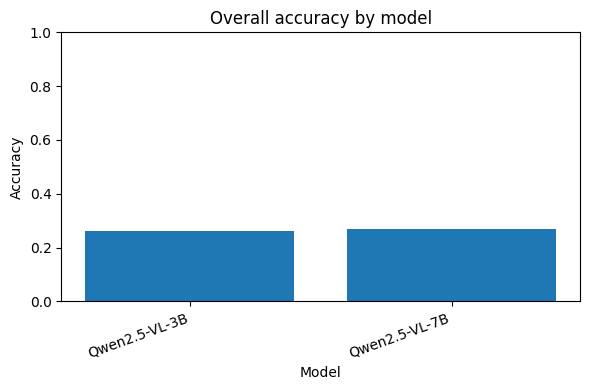

In [4]:
overall = (
    all_df.groupby("model")["correct"]
    .mean()
    .reset_index(name="accuracy")
)

display(overall)

plt.figure(figsize=(6, 4))
plt.bar(overall["model"], overall["accuracy"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Overall accuracy by model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(OUT_DIR / "overall_accuracy_by_model.png", dpi=200)
plt.show()

model,Qwen2.5-VL-3B,Qwen2.5-VL-7B
modality,,
text,0.625000,0.808333
bar,0.158333,0.158333
line,0.175000,0.141667
scatter,0.175000,0.116667
simulation,0.166667,0.125000


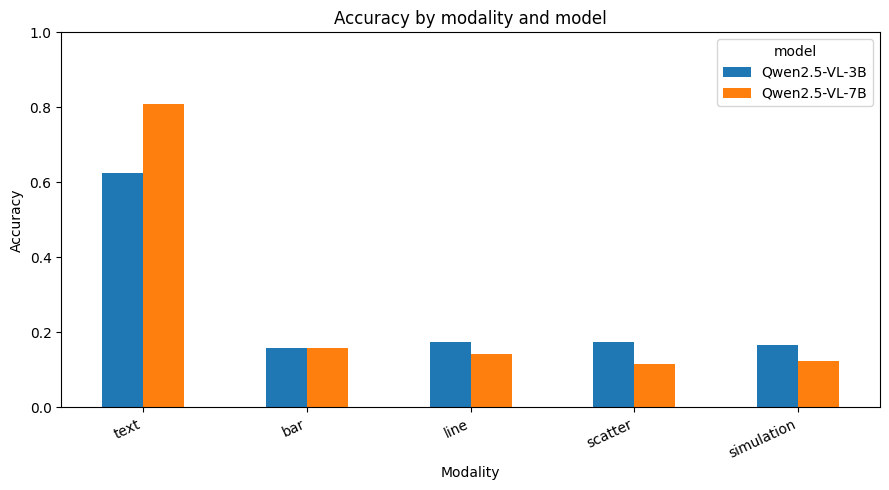

In [5]:
modality_order = ["text", "bar", "line", "scatter", "simulation"]

modality_summary = (
    all_df.groupby(["model", "modality"])["correct"]
    .mean()
    .reset_index(name="accuracy")
)

modality_pivot = modality_summary.pivot(
    index="modality",
    columns="model",
    values="accuracy",
).reindex(modality_order)

display(modality_pivot)

ax = modality_pivot.plot(kind="bar", figsize=(9, 5))
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Modality")
ax.set_title("Accuracy by modality and model")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(OUT_DIR / "accuracy_by_modality_and_model.png", dpi=200)
plt.show()

model,Qwen2.5-VL-3B,Qwen2.5-VL-7B
task_type,,
change_amount,0.05,0.15
change_direction,0.65,0.54
changed_variable,0.10,0.20
largest_drop_step,0.25,0.23
max_step,0.31,0.30
value_at_step,0.20,0.20


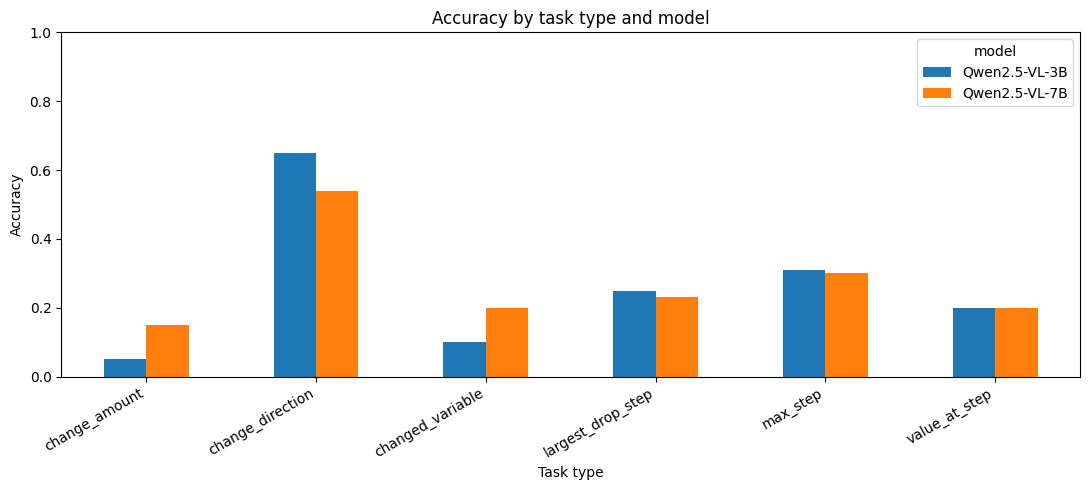

In [6]:
task_summary = (
    all_df.groupby(["model", "task_type"])["correct"]
    .mean()
    .reset_index(name="accuracy")
)

task_pivot = task_summary.pivot(
    index="task_type",
    columns="model",
    values="accuracy",
)

display(task_pivot)

ax = task_pivot.plot(kind="bar", figsize=(11, 5))
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Task type")
ax.set_title("Accuracy by task type and model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(OUT_DIR / "accuracy_by_task_and_model.png", dpi=200)
plt.show()

modality,text,bar,line,scatter,simulation
model,,,,,
Qwen2.5-VL-3B,0.625000,0.158333,0.175000,0.175000,0.166667
Qwen2.5-VL-7B,0.808333,0.158333,0.141667,0.116667,0.125000


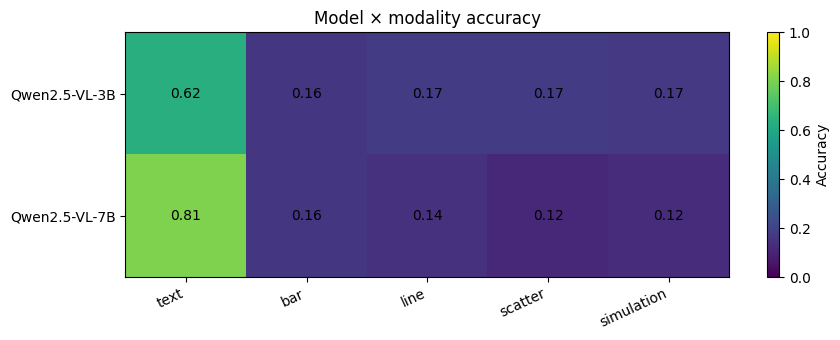

In [7]:
model_modality = (
    all_df.groupby(["model", "modality"])["correct"]
    .mean()
    .reset_index(name="accuracy")
)

heat = model_modality.pivot(
    index="model",
    columns="modality",
    values="accuracy",
).reindex(columns=modality_order)

display(heat)

plt.figure(figsize=(9, 3.5))
im = plt.imshow(heat.values, aspect="auto", vmin=0, vmax=1)

plt.xticks(range(len(heat.columns)), heat.columns, rotation=25, ha="right")
plt.yticks(range(len(heat.index)), heat.index)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        value = heat.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.colorbar(im, label="Accuracy")
plt.title("Model × modality accuracy")
plt.tight_layout()

plt.savefig(OUT_DIR / "heatmap_model_by_modality.png", dpi=200)
plt.show()

model,Qwen2.5-VL-3B,Qwen2.5-VL-7B
modality,,
text,39.150000,10.75000
bar,157.908614,67.19450
line,67.031376,67.19075
scatter,67.041706,67.40425
simulation,699640.879488,67.27255


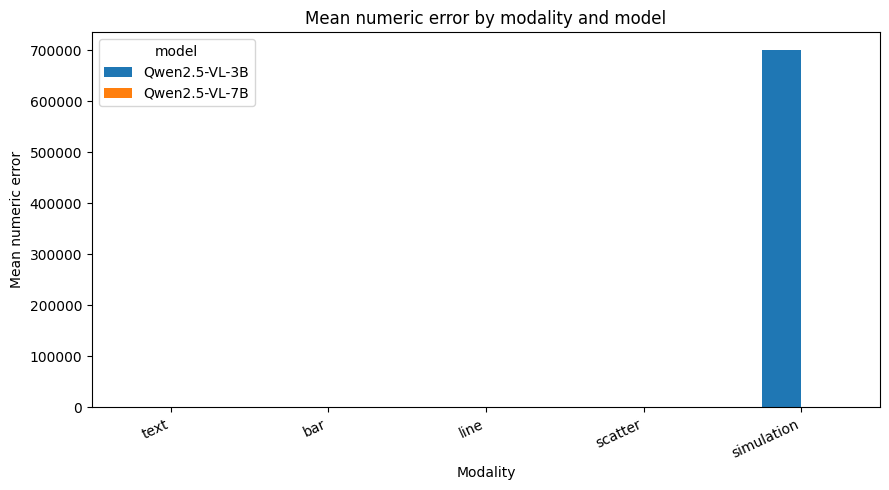

In [8]:
numeric_df = all_df[all_df["numeric_error"].notna()].copy()

numeric_summary = (
    numeric_df.groupby(["model", "modality"])["numeric_error"]
    .mean()
    .reset_index(name="mean_numeric_error")
)

numeric_pivot = numeric_summary.pivot(
    index="modality",
    columns="model",
    values="mean_numeric_error",
).reindex(modality_order)

display(numeric_pivot)

ax = numeric_pivot.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Mean numeric error")
ax.set_xlabel("Modality")
ax.set_title("Mean numeric error by modality and model")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(OUT_DIR / "mean_numeric_error_by_modality_and_model.png", dpi=200)
plt.show()

In [9]:
numeric_df = all_df[all_df["numeric_error"].notna()].copy()
numeric_df["numeric_error"] = pd.to_numeric(numeric_df["numeric_error"], errors="coerce")

top_errors = (
    numeric_df
    .sort_values("numeric_error", ascending=False)
    [[
        "model",
        "modality",
        "task_type",
        "case_id",
        "question",
        "gold_answer",
        "parsed_answer",
        "numeric_error",
        "raw_output",
    ]]
    .head(30)
)

display(top_errors)

,model,modality,task_type,case_id,question,gold_answer,parsed_answer,numeric_error,raw_output
159,Qwen2.5-VL-3B,simulation,change_amount,seq_0005__target_change_amount__simulation,By how much does absorbance change from step 0...,56.0,27981816,2.798176e+07,"```json\n{\n ""answer"": 27981816\n}\n```"
576,Qwen2.5-VL-3B,bar,change_amount,seq_0019__target_change_amount__bar,By how much does absorbance change from step 0...,-35.0,1326.8179775,1.361818e+03,"```json\n{\n ""answer"": 1326.8179775\n}\n```"
156,Qwen2.5-VL-3B,bar,change_amount,seq_0005__target_change_amount__bar,By how much does absorbance change from step 0...,56.0,1398,1.342000e+03,"```json\n{\n ""answer"": 1398\n}\n```"
64,Qwen2.5-VL-3B,simulation,value_at_step,seq_0002__read_last_target__simulation,What is the value of absorbance at step 4?,32.0,1023,9.910000e+02,"```json\n{\n ""answer"": 1023\n}\n```"
36,Qwen2.5-VL-3B,bar,change_amount,seq_0001__target_change_amount__bar,By how much does absorbance change from step 0...,-54.0,368.9,4.229000e+02,"```json\n{\n ""answer"": 368.9\n}\n```"
484,Qwen2.5-VL-3B,simulation,value_at_step,seq_0016__read_last_target__simulation,What is the value of absorbance at step 4?,56.0,360,3.040000e+02,"```json\n{\n ""answer"": 360\n}\n```"
61,Qwen2.5-VL-3B,bar,value_at_step,seq_0002__read_last_target__bar,What is the value of absorbance at step 4?,32.0,318,2.860000e+02,"```json\n{\n ""answer"": 318\n}\n```"
1171,Qwen2.5-VL-7B,bar,value_at_step,seq_0019__read_last_target__bar,What is the value of absorbance at step 4?,240.0,0.1,2.399000e+02,"{""answer"": 0.1}"
1172,Qwen2.5-VL-7B,line,value_at_step,seq_0019__read_last_target__line,What is the value of absorbance at step 4?,240.0,0.2,2.398000e+02,"{""answer"": 0.2}"
1174,Qwen2.5-VL-7B,simulation,value_at_step,seq_0019__read_last_target__simulation,What is the value of absorbance at step 4?,240.0,0.3,2.397000e+02,"{""answer"": 0.3}"


In [10]:
error_summary = (
    numeric_df
    .groupby(["model", "modality"])["numeric_error"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)

display(error_summary)

,model,modality,count,mean,median,max
0,Qwen2.5-VL-3B,bar,40,157.908614,66.003543,1.361818e+03
1,Qwen2.5-VL-3B,line,40,67.031376,52.675000,2.391237e+02
2,Qwen2.5-VL-3B,scatter,40,67.041706,53.091500,2.390817e+02
3,Qwen2.5-VL-3B,simulation,40,699640.879488,55.500000,2.798176e+07
4,Qwen2.5-VL-3B,text,40,39.150000,0.000000,2.320000e+02
5,Qwen2.5-VL-7B,bar,40,67.194500,52.800000,2.399000e+02
6,Qwen2.5-VL-7B,line,40,67.190750,52.050000,2.398000e+02
7,Qwen2.5-VL-7B,scatter,40,67.404250,53.800000,2.394000e+02
8,Qwen2.5-VL-7B,simulation,40,67.272550,53.856000,2.397000e+02
9,Qwen2.5-VL-7B,text,40,10.750000,0.000000,1.920000e+02


In [11]:
numeric_df = all_df[all_df["numeric_error"].notna()].copy()
numeric_df["numeric_error"] = pd.to_numeric(numeric_df["numeric_error"], errors="coerce")

top_errors = (
    numeric_df
    .sort_values("numeric_error", ascending=False)
    [[
        "model",
        "modality",
        "task_type",
        "case_id",
        "question",
        "gold_answer",
        "parsed_answer",
        "numeric_error",
        "raw_output",
    ]]
    .head(30)
)

display(top_errors)

,model,modality,task_type,case_id,question,gold_answer,parsed_answer,numeric_error,raw_output
159,Qwen2.5-VL-3B,simulation,change_amount,seq_0005__target_change_amount__simulation,By how much does absorbance change from step 0...,56.0,27981816,2.798176e+07,"```json\n{\n ""answer"": 27981816\n}\n```"
576,Qwen2.5-VL-3B,bar,change_amount,seq_0019__target_change_amount__bar,By how much does absorbance change from step 0...,-35.0,1326.8179775,1.361818e+03,"```json\n{\n ""answer"": 1326.8179775\n}\n```"
156,Qwen2.5-VL-3B,bar,change_amount,seq_0005__target_change_amount__bar,By how much does absorbance change from step 0...,56.0,1398,1.342000e+03,"```json\n{\n ""answer"": 1398\n}\n```"
64,Qwen2.5-VL-3B,simulation,value_at_step,seq_0002__read_last_target__simulation,What is the value of absorbance at step 4?,32.0,1023,9.910000e+02,"```json\n{\n ""answer"": 1023\n}\n```"
36,Qwen2.5-VL-3B,bar,change_amount,seq_0001__target_change_amount__bar,By how much does absorbance change from step 0...,-54.0,368.9,4.229000e+02,"```json\n{\n ""answer"": 368.9\n}\n```"
484,Qwen2.5-VL-3B,simulation,value_at_step,seq_0016__read_last_target__simulation,What is the value of absorbance at step 4?,56.0,360,3.040000e+02,"```json\n{\n ""answer"": 360\n}\n```"
61,Qwen2.5-VL-3B,bar,value_at_step,seq_0002__read_last_target__bar,What is the value of absorbance at step 4?,32.0,318,2.860000e+02,"```json\n{\n ""answer"": 318\n}\n```"
1171,Qwen2.5-VL-7B,bar,value_at_step,seq_0019__read_last_target__bar,What is the value of absorbance at step 4?,240.0,0.1,2.399000e+02,"{""answer"": 0.1}"
1172,Qwen2.5-VL-7B,line,value_at_step,seq_0019__read_last_target__line,What is the value of absorbance at step 4?,240.0,0.2,2.398000e+02,"{""answer"": 0.2}"
1174,Qwen2.5-VL-7B,simulation,value_at_step,seq_0019__read_last_target__simulation,What is the value of absorbance at step 4?,240.0,0.3,2.397000e+02,"{""answer"": 0.3}"


In [12]:
error_summary_robust = (
    numeric_df
    .groupby(["model", "modality"])["numeric_error"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        p75=lambda x: x.quantile(0.75),
        p95=lambda x: x.quantile(0.95),
        max="max",
    )
    .reset_index()
)

display(error_summary_robust)

,model,modality,count,mean,median,p75,p95,max
0,Qwen2.5-VL-3B,bar,40,157.908614,66.003543,137.250000,468.855000,1.361818e+03
1,Qwen2.5-VL-3B,line,40,67.031376,52.675000,84.457825,200.180692,2.391237e+02
2,Qwen2.5-VL-3B,scatter,40,67.041706,53.091500,77.733530,200.744121,2.390817e+02
3,Qwen2.5-VL-3B,simulation,40,699640.879488,55.500000,112.930000,338.350000,2.798176e+07
4,Qwen2.5-VL-3B,text,40,39.150000,0.000000,67.000000,193.400000,2.320000e+02
5,Qwen2.5-VL-7B,bar,40,67.194500,52.800000,83.775000,200.792000,2.399000e+02
6,Qwen2.5-VL-7B,line,40,67.190750,52.050000,84.275000,200.235000,2.398000e+02
7,Qwen2.5-VL-7B,scatter,40,67.404250,53.800000,84.665000,200.795000,2.394000e+02
8,Qwen2.5-VL-7B,simulation,40,67.272550,53.856000,83.750000,200.801500,2.397000e+02
9,Qwen2.5-VL-7B,text,40,10.750000,0.000000,0.000000,90.900000,1.920000e+02


In [13]:
import numpy as np

change_df = all_df[all_df["task_type"] == "change_amount"].copy()

change_df["gold_num"] = pd.to_numeric(change_df["gold_answer"], errors="coerce")
change_df["pred_num"] = pd.to_numeric(change_df["parsed_answer"], errors="coerce")

tol = 0.01

change_df["correct_signed"] = np.isclose(
    change_df["pred_num"],
    change_df["gold_num"],
    atol=tol,
    equal_nan=False,
)

change_df["correct_abs"] = np.isclose(
    change_df["pred_num"].abs(),
    change_df["gold_num"].abs(),
    atol=tol,
    equal_nan=False,
)

change_df["sign_error_only"] = (
    (~change_df["correct_signed"]) & change_df["correct_abs"]
)

sign_summary = (
    change_df
    .groupby(["model", "modality"])
    .agg(
        n=("case_id", "count"),
        signed_accuracy=("correct_signed", "mean"),
        abs_accuracy=("correct_abs", "mean"),
        sign_error_rate=("sign_error_only", "mean"),
    )
    .reset_index()
)

display(sign_summary)

,model,modality,n,signed_accuracy,abs_accuracy,sign_error_rate
0,Qwen2.5-VL-3B,bar,20,0.00,0.00,0.00
1,Qwen2.5-VL-3B,line,20,0.00,0.00,0.00
2,Qwen2.5-VL-3B,scatter,20,0.00,0.00,0.00
3,Qwen2.5-VL-3B,simulation,20,0.00,0.00,0.00
4,Qwen2.5-VL-3B,text,20,0.25,0.70,0.45
5,Qwen2.5-VL-7B,bar,20,0.00,0.05,0.05
6,Qwen2.5-VL-7B,line,20,0.00,0.00,0.00
7,Qwen2.5-VL-7B,scatter,20,0.00,0.00,0.00
8,Qwen2.5-VL-7B,simulation,20,0.00,0.00,0.00
9,Qwen2.5-VL-7B,text,20,0.75,0.90,0.15


In [14]:
category_df = all_df[all_df["answer_type"] == "category"].copy()

for task in category_df["task_type"].unique():
    print("\nTASK:", task)
    display(
        category_df[category_df["task_type"] == task]
        .groupby(["model", "modality", "parsed_answer"])
        .size()
        .reset_index(name="count")
        .sort_values(["model", "modality", "count"], ascending=[True, True, False])
        .head(50)
    )


TASK: change_direction


,model,modality,parsed_answer,count
0,Qwen2.5-VL-3B,bar,decrease,17
1,Qwen2.5-VL-3B,bar,increase,3
2,Qwen2.5-VL-3B,line,decrease,20
3,Qwen2.5-VL-3B,scatter,decrease,17
4,Qwen2.5-VL-3B,scatter,increase,3
5,Qwen2.5-VL-3B,simulation,decrease,20
6,Qwen2.5-VL-3B,text,decrease,15
8,Qwen2.5-VL-3B,text,same,3
7,Qwen2.5-VL-3B,text,increase,2
9,Qwen2.5-VL-7B,bar,decrease,15



TASK: changed_variable


,model,modality,parsed_answer,count
0,Qwen2.5-VL-3B,bar,a,2
1,Qwen2.5-VL-3B,bar,b,2
3,Qwen2.5-VL-3B,bar,funding,2
5,Qwen2.5-VL-3B,bar,input_variable_2,2
14,Qwen2.5-VL-3B,bar,x,2
2,Qwen2.5-VL-3B,bar,d,1
4,Qwen2.5-VL-3B,bar,input_2,1
6,Qwen2.5-VL-3B,bar,k,1
7,Qwen2.5-VL-3B,bar,number_of_employees,1
8,Qwen2.5-VL-3B,bar,number_of_students,1


In [15]:
changed_df = all_df[all_df["task_type"] == "changed_variable"].copy()

display(
    changed_df[
        [
            "model",
            "modality",
            "question",
            "gold_answer",
            "parsed_answer",
            "correct",
            "raw_output",
        ]
    ].sample(30, random_state=42)
)

,model,modality,question,gold_answer,parsed_answer,correct,raw_output
585,Qwen2.5-VL-3B,text,Which input variable changed from step 0 to st...,wavelength,wavelength,True,"{""answer"": ""wavelength""}"
105,Qwen2.5-VL-3B,text,Which input variable changed from step 0 to st...,wavelength,concentration,False,"{\n ""answer"": ""concentration""\n}"
195,Qwen2.5-VL-3B,text,Which input variable changed from step 0 to st...,wavelength,wavelength,True,"{\n ""answer"": ""wavelength""\n}"
948,Qwen2.5-VL-7B,scatter,Which input variable changed from step 0 to st...,path_length,increase,False,"{""answer"": ""increase""}"
768,Qwen2.5-VL-7B,scatter,Which input variable changed from step 0 to st...,path_length,y,False,"{""answer"": ""y""}"
705,Qwen2.5-VL-7B,text,Which input variable changed from step 0 to st...,wavelength,wavelength,True,"{\n ""answer"": ""wavelength""\n}"
409,Qwen2.5-VL-3B,simulation,Which input variable changed from step 0 to st...,wavelength,input-brightness,False,"{""answer"": ""input-brightness""}"
1035,Qwen2.5-VL-7B,text,Which input variable changed from step 0 to st...,wavelength,wavelength,True,"{""answer"": ""wavelength""}"
1039,Qwen2.5-VL-7B,simulation,Which input variable changed from step 0 to st...,wavelength,same,False,"{""answer"": ""same""}"
285,Qwen2.5-VL-3B,text,Which input variable changed from step 0 to st...,path_length,concentration,False,"{\n ""answer"": ""concentration""\n}"
